## Classify Microscopic Histopathology Images

In [36]:
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset
torch.manual_seed(42)

class PCamDataset(Dataset):
    """
    Custom Dataset for loading the microscopic histopathology images within the PCam dataset
    """
    def __init__(self, csv_file, transform=None, num_samples=None):
        """
        Args:
            csv_file (string): Path to the csv file with annotations
            transform (callable, optional): Optional transform to be applied on a sample
            num_samples (int, optional): Number of samples to load. If None, loads all samples
        """
        self.annotations = pd.read_csv(csv_file)
        if num_samples is not None:
            self.annotations = self.annotations.head(num_samples)
        self.transform = transform
        
    def __len__(self):
        return len(self.annotations)
    
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
            
        # Get image path and label
        img_path = self.annotations.iloc[idx, 0]
        label = self.annotations.iloc[idx, 1]
        
        # Load and convert image
        image = Image.open(img_path)
        if image.mode != 'RGB':
            image = image.convert('RGB')
            
        if self.transform:
            image = self.transform(image)
            
        # Convert label to float
        label = torch.tensor(label, dtype=torch.float)
            
        return image, label

### CNN Pre-Processing

In [37]:
from torchvision import transforms
torch.manual_seed(42)

train_transform = transforms.Compose([
    transforms.Resize((96,96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(), # with values ranging from [0.0, 1.0]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [38]:
torch.manual_seed(42)
train_dataset = PCamDataset(csv_file='data/train_labels.csv', transform=train_transform)

In [39]:
from torch.utils.data import DataLoader
torch.manual_seed(42)

train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)

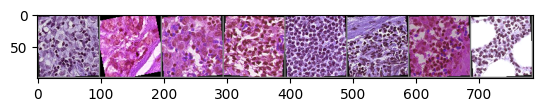

  1.0   1.0   0.0   1.0   0.0   1.0   1.0   0.0


In [40]:
# Visualize the first training batch
import torchvision
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get a batch of training data
dataiter = iter(train_dataloader)
images, labels = next(dataiter)
batch_size = 8

# Show images
imshow(torchvision.utils.make_grid(images))
# Print labels
print(' '.join('%5s' % labels[j].item() for j in range(batch_size)))

In [41]:
val_test_transform = transforms.Compose([
    transforms.Resize((96,96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [42]:
val_dataset = PCamDataset(csv_file='data/validation_labels.csv', transform=val_test_transform)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [43]:
test_dataset = PCamDataset(csv_file='data/test_labels.csv', transform=val_test_transform)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### CNN Training

create a CNN architecture as a class named `SimpleCNN` using the `nn.Module`.

In [44]:
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(42)

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 12 * 12, 256)
        self.fc2 = nn.Linear(256, 1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x)).squeeze(1)
        return x

cnn_model = SimpleCNN()

Set the CNN hardware device to GPU/CPU.

Move the `cnn_model` to the available device.

In [45]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cnn_model.to(device)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=18432, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=1, bias=True)
)

initialize the loss function and optimizer for training.

In [46]:
import torch.optim as optim
torch.manual_seed(42)

criterion = nn.BCELoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.0005)

In [47]:
torch.manual_seed(42)
train_losses = []
val_losses = []

num_epochs = 5
for epoch in range(num_epochs):
    total_train_loss = 0
    total_val_loss = 0

    # Training
    cnn_model.train()
    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = cnn_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
        
    # Validation
    cnn_model.eval()
    with torch.no_grad():
        for images, labels in val_dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = cnn_model(images)
            val_loss = criterion(outputs, labels)
            total_val_loss += val_loss.item()

    # Calculate average losses
    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_val_loss = total_val_loss / len(val_dataloader)

    # Save the average training and validation losses
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    # Print training and validation losses
    print(f"Epoch [{epoch+1}/{num_epochs}]: Training Loss: {avg_train_loss:.4f} - Validation Loss: {avg_val_loss:.4f}")

Epoch [1/5]: Training Loss: 0.6517 - Validation Loss: 0.6193
Epoch [2/5]: Training Loss: 0.5506 - Validation Loss: 0.5406
Epoch [3/5]: Training Loss: 0.5838 - Validation Loss: 0.5248
Epoch [4/5]: Training Loss: 0.5406 - Validation Loss: 0.5080
Epoch [5/5]: Training Loss: 0.5041 - Validation Loss: 0.5089


Visualize the training and validation losses during training.

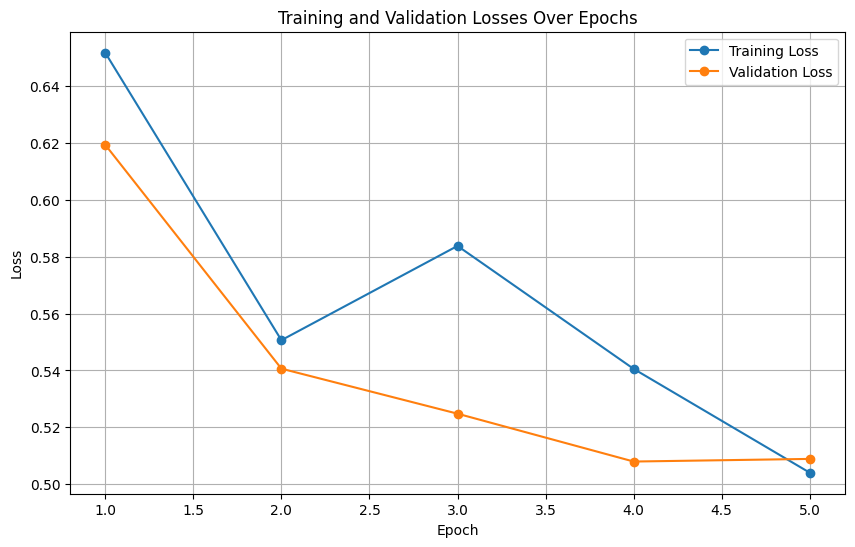

In [48]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label='Training Loss', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

use our trained CNN that we've loaded and saved to the variable `cnn_model` to generate predictions (labels and probabilities) on the testing set images.

In [49]:
test_pred_probs = []
test_pred_labels = []

with torch.no_grad():
    for images, labels in test_dataloader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = cnn_model(images)
        
        test_pred_probs.extend(outputs.cpu().numpy())
        
        pred_labels = torch.round(outputs)
        test_pred_labels.extend(pred_labels.cpu().numpy())

# show output 
print("First image predicted probabilities:", test_pred_probs[0])
print("First image predicted label:", test_pred_labels[0])

First image predicted probabilities: 0.89919394
First image predicted label: 1.0


### Evaluation

In [50]:
from sklearn.metrics import classification_report

report = classification_report(test_true_labels, test_pred_labels, target_names=pcam_classes)
print(report)

              precision    recall  f1-score   support

      Normal       0.82      0.77      0.79        97
       Tumor       0.80      0.83      0.82       103

    accuracy                           0.81       200
   macro avg       0.81      0.80      0.80       200
weighted avg       0.81      0.81      0.80       200



### Conclusion

There's definitely a lot of room for improvement:

- experiment with different augmetation techniques (it may be useful to research techniques that are specific to medical imaging)
- explore different model architectures (like adding more layers, different activation functions, change the # of neurons)
- explore different loss functions or optimizers with varying learning rates

In the real-world, medical AI systems require extensive testing before applying them to real patients. For example, a few crucial things to consider:

- optimizing for accuracy may not always be appropriate 
- understanding the trade-offs between precision and recall (false positives and false negatives)
- robustness across different imaging conditions
- the importance of model interpretability for trust among clinical practitioners and patients
- the importance of consulting with medical professionals to provide valuable insights with their expertise